In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallamahgoub/diabetes")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes' dataset.
Path to dataset files: /kaggle/input/diabetes


In [ ]:
df = pd.read_csv("/kaggle/input/diabetes/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.info()
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    i

(768, 9)

In [ ]:
df.columns = df.columns.str.strip()
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'Pedigree', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
x = df.drop("Outcome", axis=1)
y = df["Outcome"]


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
dt = DecisionTreeClassifier(

    random_state=42,
    )
cv_scores = cross_val_score(dt,x,y,cv=4)
print("\n5-Fold CV Scores:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))




5-Fold CV Scores: [0.71354167 0.66145833 0.73958333 0.71354167]
Mean CV accuracy: 0.70703125


In [ ]:
param_grid = {
    'criterion' : ['gini', 'entropy'],
    'max_depth' : [None ,3,4,5],
    'min_samples_split': [3,4,5]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv = 5)
grid_search.fit(x_train, y_train)

best_params = grid_search.best_params_
print("\nBest hyperparameters: ", best_params)
print("Best CV score from grid search: ", grid_search.best_score_)



Best hyperparameters:  {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 3}
Best CV score from grid search:  0.7460082633613221


In [ ]:
best_dt = grid_search.best_estimator_

y_pred = best_dt.predict(x_test)
print("\nTest set accuracy: ", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, ))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Test set accuracy:  0.6948051948051948

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.92      0.80       100
           1       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154

Confusion Matrix:
 [[92  8]
 [39 15]]


In [ ]:
''' importance = pd.DataFrame({
    "Feature": x.columns,
    "Imortance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", asceding=False)

print("/nTop 15 Imortant Features:")
print(importance.head(15)) '''






importance = pd.DataFrame({

    'Feature': x.columns,
    'Importance': best_dt.feature_importances_
    #'Importance': importances
})

importance = importance.sort_values(by='Importance', ascending=False)

print("\nTop Important Features:")

print(importance.head(15))


Top Important Features:
         Feature  Importance
1        Glucose    0.543729
5            BMI    0.258708
7            Age    0.132158
0    Pregnancies    0.065405
3  SkinThickness    0.000000
2  BloodPressure    0.000000
4        Insulin    0.000000
6       Pedigree    0.000000


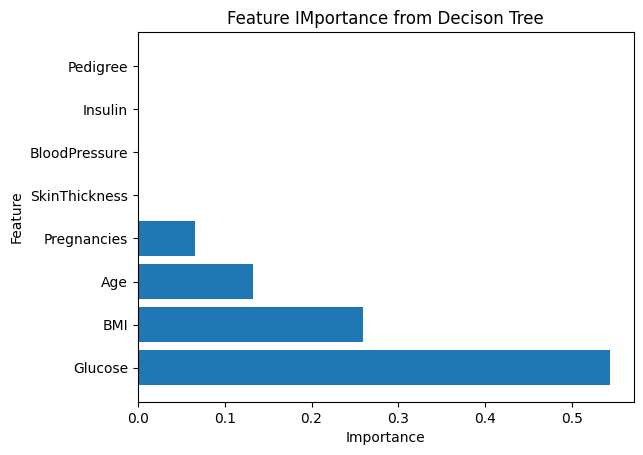

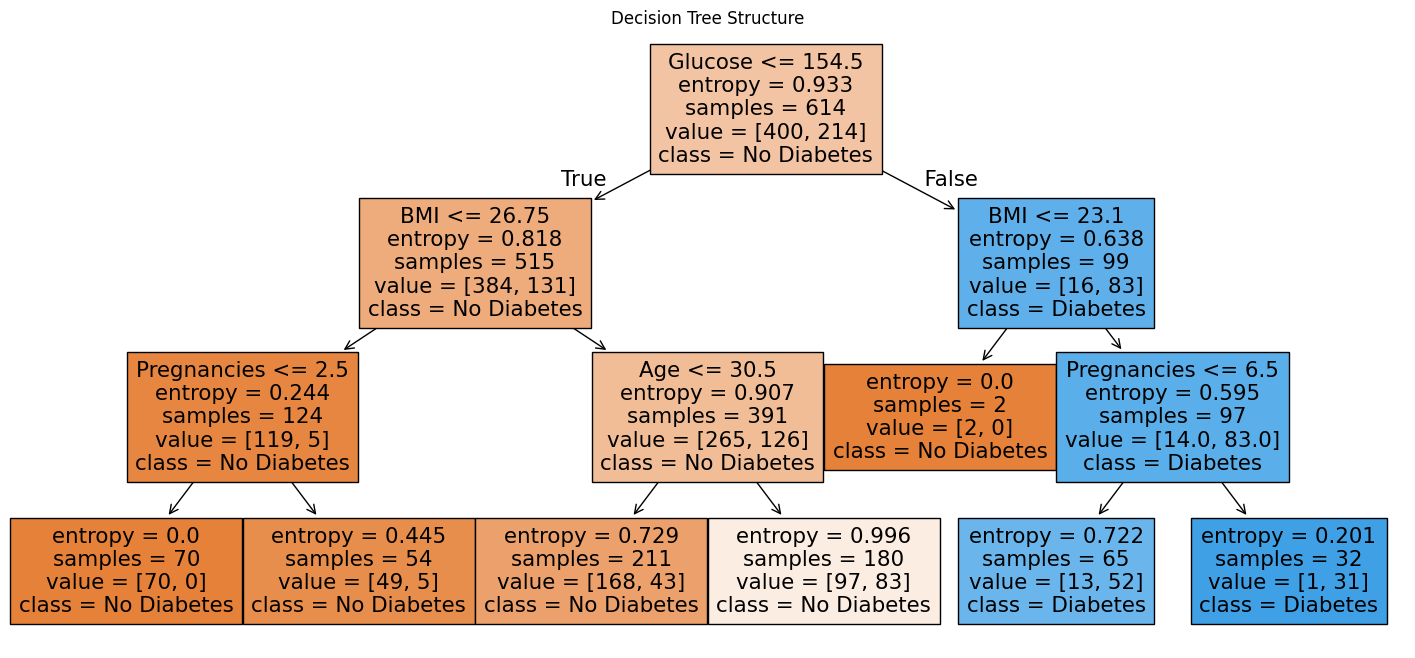

In [ ]:
plt.figure()
plt.barh(importance['Feature'], importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature IMportance from Decison Tree")
plt.show()

plt.figure(figsize=(18,8))
plot_tree(
    best_dt,
    feature_names=x.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True
)

plt.title("Decision Tree Structure")
plt.show()